In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
# Load dataset
df = pd.read_csv("superstore_sales_dataset.csv")

# Show first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [5]:
# Check missing values
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [7]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [8]:
# Selecting important columns
data = df[['Sales']]

# Display data
data.head()

,Sales
0,261.9600
1,731.9400
2,14.6200
3,957.5775
4,22.3680


In [9]:
# Selecting useful columns
data = df[['Category', 'Region', 'Segment', 'Sales']]

# Display first rows
data.head()

,Category,Region,Segment,Sales
0,Furniture,South,Consumer,261.9600
1,Furniture,South,Consumer,731.9400
2,Office Supplies,West,Corporate,14.6200
3,Furniture,South,Consumer,957.5775
4,Office Supplies,South,Consumer,22.3680


In [10]:
# Convert categorical columns into numeric values
data = pd.get_dummies(data)

# Display updated data
data.head()

,Sales,Category_Furniture,Category_Office Supplies,Category_Technology,Region_Central,Region_East,Region_South,Region_West,Segment_Consumer,Segment_Corporate,Segment_Home Office
0,261.9600,True,False,False,False,False,True,False,True,False,False
1,731.9400,True,False,False,False,False,True,False,True,False,False
2,14.6200,False,True,False,False,False,False,True,False,True,False
3,957.5775,True,False,False,False,False,True,False,True,False,False
4,22.3680,False,True,False,False,False,True,False,True,False,False


In [11]:
# Features
X = data.drop('Sales', axis=1)

# Target
y = data['Sales']

In [12]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
# Train model
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [14]:
# Predictions
y_pred = model.predict(X_test)

print(y_pred[:5])

[342.625  126.25   411.75   125.8125 117.1875]


In [15]:
# Accuracy
print("R2 Score:", r2_score(y_test, y_pred))

print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.04085044900772905
MAE: 274.8422891836735


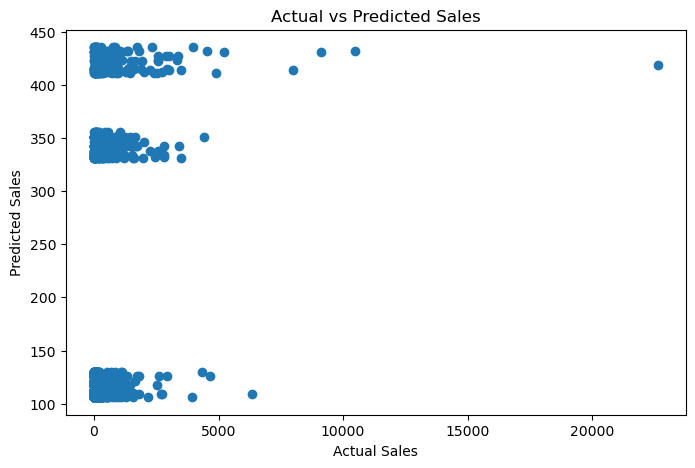

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

In [17]:
import joblib

# Save model
joblib.dump(model, 'sales_prediction_model.pkl')

print("Model saved successfully!")

Model saved successfully!
